## Imports

In [1]:
import cv2 as cv # OpenCV (Open Source Computer Vision Library) 
import numpy as np
import matplotlib.pyplot as plt

import Functions as func
import Vis as vis

## Creation: codes before organization

In [2]:
def pre_processing(in_video_path, out_video_path, num_frames, fps = None, scale = .2, roi = None):
    # carrega o vídeo
    video = cv.VideoCapture(in_video_path)
    
    # lança uma exceção caso ocorra algum erro no carregamento
    if not video.isOpened():
        raise IOError("Erro ao abrir o vídeo")

    # especifica o FPS do vídeo de saída
    # duas possibilidades: 
    # 1. ou o usuário especifica o FPS ou
    # 2. usa o mesmo fps do vídeo de entrada
    if fps is None:
        fps = video.get(cv.CAP_PROP_FPS)
    
    # lógica para orientar o vídeo de saída
    if roi is not None:
        x, y, w, h = roi
        base_w, base_h = w, h
    else:
        base_w = int(video.get(cv.CAP_PROP_FRAME_WIDTH))
        base_h = int(video.get(cv.CAP_PROP_FRAME_HEIGHT))

    width = int(base_w * scale)
    height = int(base_h * scale)
    
    fourcc = cv.VideoWriter_fourcc(*"mp4v")
    out = cv.VideoWriter(out_video_path, fourcc, fps, (width, height), isColor = False)
    
    count = 0
    
    while count < num_frames:
        ret, frame = video.read()
        if not ret:
            break
            
        # frame = cv.rotate(frame, cv.ROTATE_180) # precisa de mais refinamento, nem sempre será 180 graus
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY) # o código original transformava em escala de cinza
        
        if roi is not None:
            gray = gray[y : y + h, x : x + w] # recorta somente cena de interesse, por enquanto esse passo é manual
        
        gray_small = cv.resize(gray, (width, height), interpolation = cv.INTER_AREA)
        out.write(gray_small)
        count += 1

    video.release()
    out.release()
    cv.destroyAllWindows()
    
def extract_signal(video_path):
    cap = cv.VideoCapture(video_path)

    ret, prev = cap.read()
    if not ret:
        raise RuntimeError("Erro ao abrir vídeo")

    if prev.ndim == 3:
        prev = prev[:, :, 0]
        
    prev = prev.astype(np.float32)

    signal = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame.ndim == 3:
            frame = frame[:, :, 0]
            
        frame = frame.astype(np.float32)

        # Diferença temporal
        diff = cv.absdiff(frame, prev)

        # Soma por coluna (movimento lateral)
        col_sum = np.sum(diff, axis=0)

        # Centroide no eixo X
        x_positions = np.arange(len(col_sum))

        if np.sum(col_sum) > 0:
            cx = np.sum(x_positions * col_sum) / np.sum(col_sum)
        else:
            cx = 0

        signal.append(cx)

        prev = frame

    cap.release()

    signal = np.array(signal)

    # Remove tendência DC
    signal -= np.mean(signal)

    return signal

def compute_fft(signal, fps):
    N = len(signal)

    # janela de Hanning (melhora muito o espectro)
    window = np.hanning(N)
    signal = signal * window # Multiplica o sinal por uma janela suave que começa e termina em zero. (Evita descontinuidade nas bordas → vazamento espectral (spectral leakage).)

    freqs = np.fft.rfftfreq(N, d = 1 / fps) # retorna só frequências positivas
    fft_vals = np.abs(np.fft.rfft(signal)) # aplica a fft, obtém valores complexos e depois a amplitude com o módulo

    return freqs, fft_vals

## Main

#### One video execution

In [ ]:
video_name = 'VID_20260308_094458267'
in_video_path = 'videos/' + vide_name + '.mp4'
out_video_path = 'out/' + video_name + '.mp4'
reduction_factor = 0.2  # reduz resolução
max_frames = None       # use None para carregar o vídeo inteiro
# func.roi_selection(in_video_path)
pre_processing(in_video_path, out_video_path, 400, 240, .2, (168, 610, 769, 867))
signal = extract_signal(out_video_path)
vis.plot_signal(signal)

freqs, fft_vals = compute_fft(signal, 240)
vis.plot_freq(freqs, fft_vals, names = , save = True)
peaks = func.get_top_n_peaks(freqs, fft_vals, n = 10)
for f, a in peaks:
    print(f"Frequência: {f:.2f} Hz | Intensidade: {a:.2f}")

### Multiple video execution

In [8]:
video_names = ['VID_20260308_094458267', 'VID_20260308_095011813', 'VID_20260308_095057386']
in_video_path = list(map(lambda x: 'videos/' + x + '.mp4', video_names))
out_video_path = list(map(lambda x: 'out/' + x + '.mp4', video_names))

reduction_factor = 0.2  # reduz resolução
max_frames = None       # use None para carregar o vídeo inteiro
fps = 120               # fps da gravação

In [9]:
# Executa somente uma vez para pré-processar o vídeo
# func.roi_selection(in_video_path)

rois = [[173, 618, 777, 854], [168, 597, 709, 877], [168, 610, 769, 867]]

for input_v, output_v, roi in zip(in_video_path, out_video_path, rois):
    print(f'{input_v} pre-processing...', end = ' ')
    pre_processing(input_v, output_v, 400, fps, reduction_factor, roi)    
    print('done.')

videos/VID_20260308_094458267.mp4 pre-processing... done.
videos/VID_20260308_095011813.mp4 pre-processing... done.
videos/VID_20260308_095057386.mp4 pre-processing... done.


In [10]:
signals = []
for output_v in out_video_path:
    print(f'{output_v} extracting signal...', end = ' ')
    signals.append(extract_signal(output_v))
    print('done.')

out/VID_20260308_094458267.mp4 extracting signal... done.
out/VID_20260308_095011813.mp4 extracting signal... done.
out/VID_20260308_095057386.mp4 extracting signal... done.


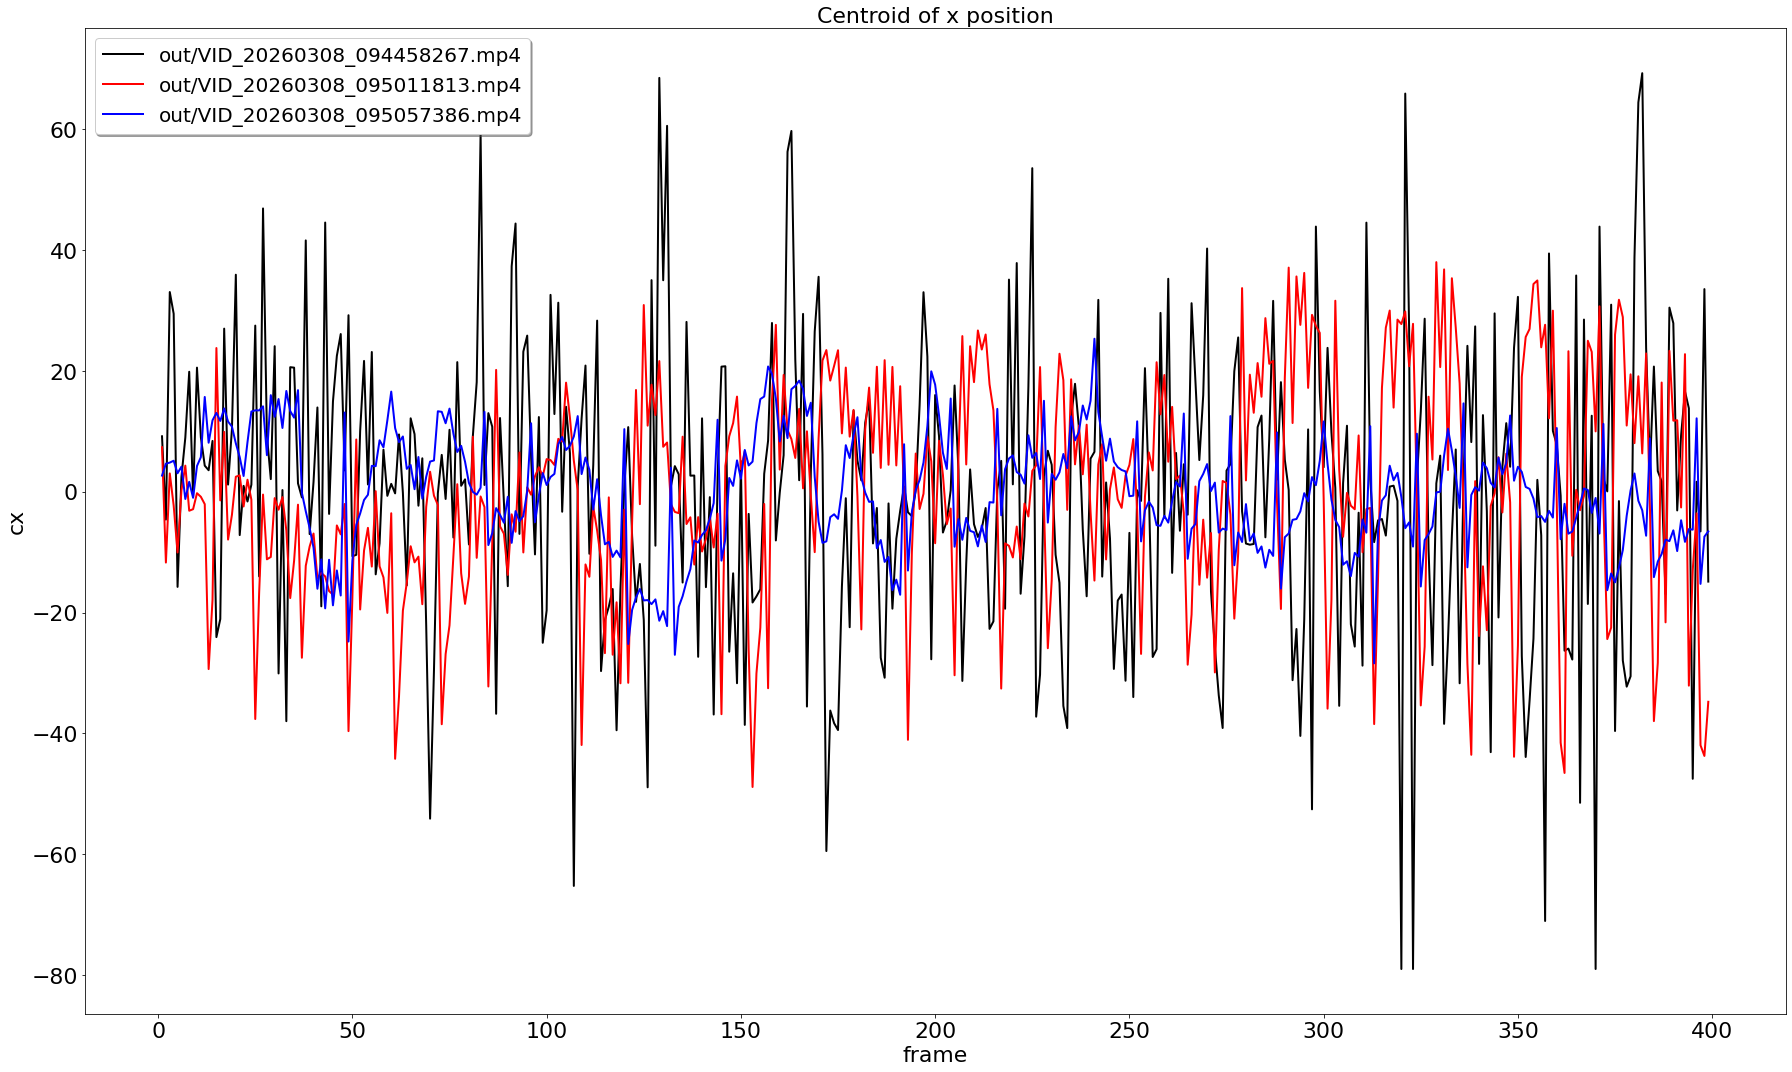

In [11]:
vis.plot_signals(signals, out_video_path, False, 25, 15)

out/VID_20260308_094458267.mp4 applying fft... done.
out/VID_20260308_095011813.mp4 applying fft... done.
out/VID_20260308_095057386.mp4 applying fft... done.


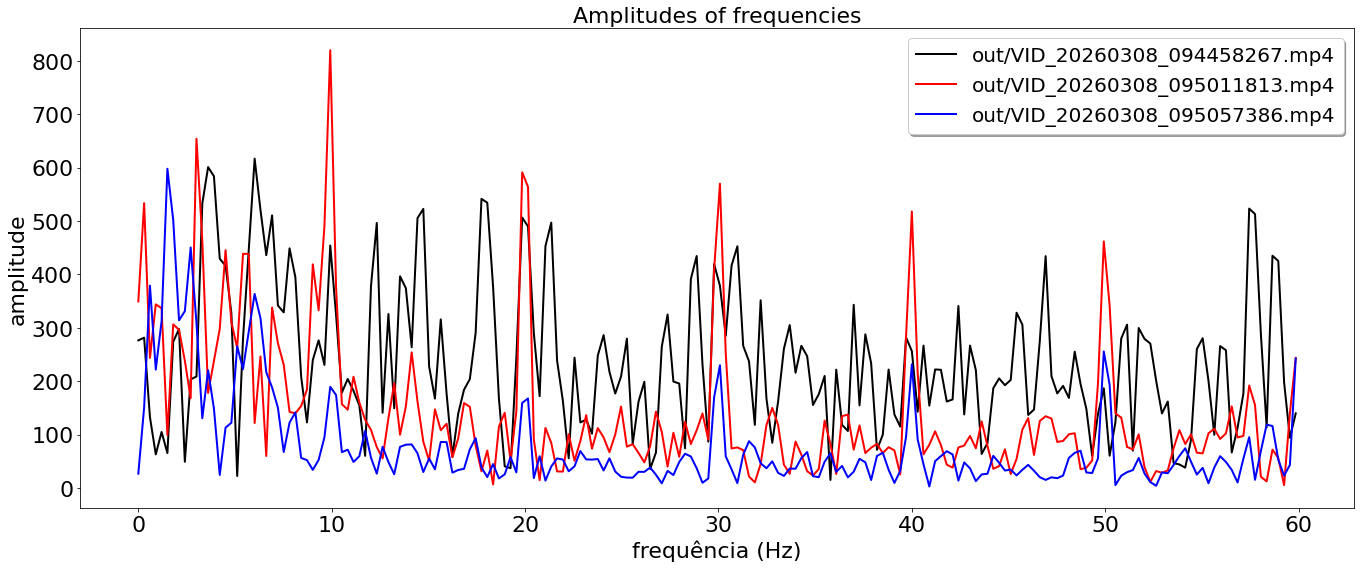

In [12]:
freqs = []
fft_vals = []

for i, signal in enumerate(signals):
    print(f'{out_video_path[i]} applying fft...', end = ' ')
    f, fft = compute_fft(signal, fps)
    freqs.append(f)
    fft_vals.append(fft)
    print('done.')

vis.plot_freqs(freqs, fft_vals, out_video_path, save = True)

# peaks = func.get_top_n_peaks(freqs, fft_vals, n = 10)
# for f, a in peaks:
#     print(f"Frequência: {f:.2f} Hz | Intensidade: {a:.2f}")

### Fast tests: execution for tests only

In [41]:
cap = cv.VideoCapture(out_video_path)
_, frame1 = cap.read()
_, frame2 = cap.read()
frame1 = frame1[:,:,0]
frame2 = frame2[:,:,0]
diff = cv.absdiff(frame1, frame2)
col_sum = np.sum(diff, axis=0)
x_positions = np.arange(len(col_sum))

In [ ]:
func.roi_selection(in_video_path)

In [6]:
func.video_status(in_video_path)

PATH = videos/testbed/20260207/240/VID_20260207_081701560.mp4
FPS = 30
WIDTH, HEIGHT = 720, 1280
FRAME COUNT = 2586
DURATION (s) = 86.2
MODE = BGR
SHAPE = (1280, 720, 3)
ROTATION = 270
